In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from scipy.optimize import curve_fit

# Style
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

# Load data
df = pd.read_csv('/Users/pablovazquez/GALA_hole/build/sipm_events.txt', sep='\t')
print(f"Loaded {len(df)} events")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Loaded 100000 events

Columns: ['event_id', 'photons_in_SiPM', 'dark_counts', 'sipm_nPE', 'sipm_charge_pe', 'primary_x', 'primary_y', 'primary_z', 'first_sipm_x', 'first_sipm_y', 'first_sipm_z']

First few rows:


,event_id,photons_in_SiPM,dark_counts,sipm_nPE,sipm_charge_pe,primary_x,primary_y,primary_z,first_sipm_x,first_sipm_y,first_sipm_z
0,0,14,0,5,5.21734,0.664074,1.418810,0.5,0.678257,-0.094827,-3.0
1,1,16,2,6,6.05536,2.093730,0.632036,0.5,-0.032731,0.372178,-3.0
2,2,17,0,5,4.89033,0.858231,-0.389866,0.5,-1.286260,1.424330,-3.0
3,3,8,1,2,2.00631,-0.500797,-1.775040,0.5,-0.913895,-0.597986,-3.0
4,4,11,3,2,1.97757,-1.191510,-1.027410,0.5,-0.597243,-0.790830,-3.0


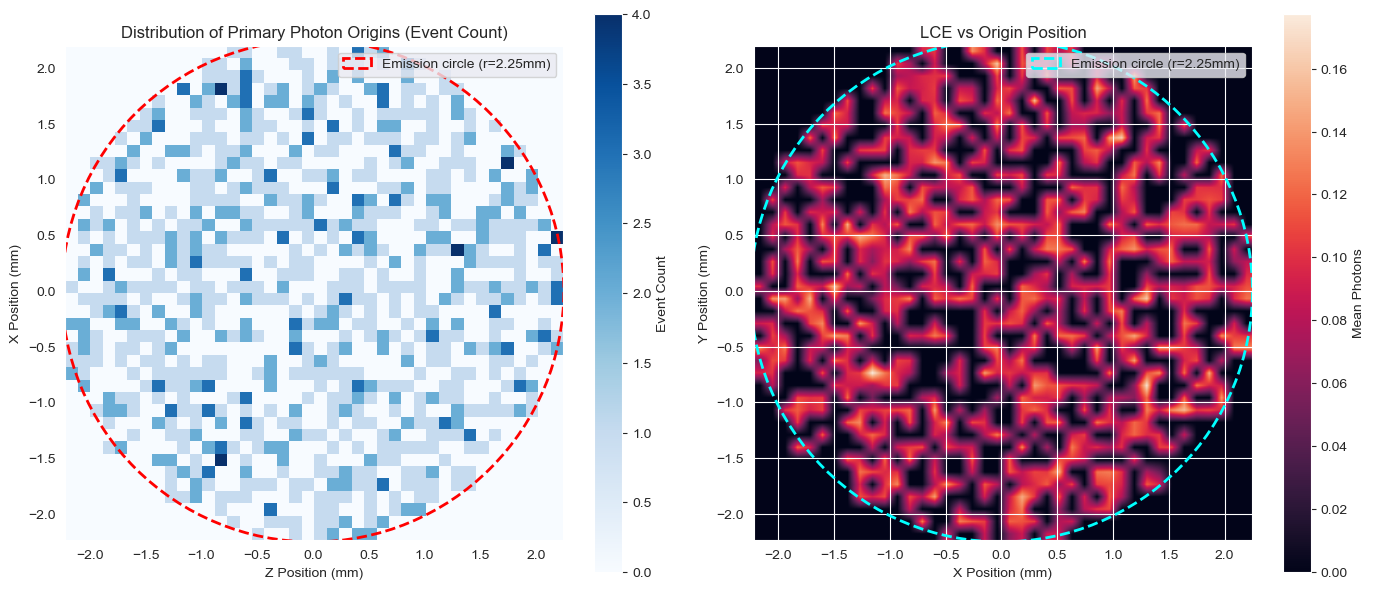


Photon Origin Statistics:
  Mean distance from center: 1.513 mm
  Max distance from center: 2.249 mm
  Average photons reaching SiPM: 28554.08
  Max photons in single event: 34688


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mapa 2D: CONTEO de eventos por región
ax = axes[0]
h_count = ax.hist2d(df['primary_x'], df['primary_y'], bins=40, cmap='Blues')
circle = plt.Circle((0, 0), 2.25, fill=False, edgecolor='red', linewidth=2, linestyle='--', label='Emission circle (r=2.25mm)')
ax.add_patch(circle)
ax.set_xlabel('Z Position (mm)')
ax.set_ylabel('X Position (mm)')
ax.set_title('Distribution of Primary Photon Origins (Event Count)')
ax.set_aspect('equal')
ax.legend()
plt.colorbar(h_count[3], ax=ax, label='Event Count')

# Mapa 2D: PROMEDIO de fotones detectados por región
# Usar hist2d directamente con los pesos de fotones
ax = axes[1]

# Crear histograma 2D de la suma de fotones
hist_sum, xedges, yedges = np.histogram2d(
    df['primary_x'], df['primary_y'], 
    bins=40, 
    weights=df['sipm_charge_pe']
)

# Crear histograma 2D del conteo
hist_count, _, _ = np.histogram2d(
    df['primary_x'], df['primary_y'], 
    bins=40
)

# Calcular el promedio (evitando división por cero)
hist_mean = np.divide(hist_sum, hist_count, where=(hist_count > 0), out=np.zeros_like(hist_sum))/300

# Usar pcolormesh con la transposición correcta
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
im = ax.imshow(hist_mean.T, extent=extent, origin='lower', aspect='auto', interpolation='bilinear')
circle = plt.Circle((0, 0), 2.25, fill=False, edgecolor='cyan', linewidth=2, linestyle='--', label='Emission circle (r=2.25mm)')
ax.add_patch(circle)
ax.set_xlabel('X Position (mm)')
ax.set_ylabel('Y Position (mm)')
ax.set_title('LCE vs Origin Position')
ax.set_aspect('equal')
ax.legend()
cbar = plt.colorbar(im, ax=ax, label='Mean Photons')

plt.tight_layout()
plt.show()

print(f"\nPhoton Origin Statistics:")
r_origin = np.sqrt(df['primary_x']**2 + df['primary_y']**2)
print(f"  Mean distance from center: {r_origin.mean():.3f} mm")
print(f"  Max distance from center: {r_origin.max():.3f} mm")
print(f"  Average photons reaching SiPM: {df['photons_in_SiPM'].mean():.2f}")
print(f"  Max photons in single event: {df['photons_in_SiPM'].max()}")

In [3]:
counts_radial, bins_radial, _ = stats.binned_statistic(r_origin.to_numpy(), df['sipm_charge_pe'].to_numpy(), statistic='mean', bins=30)
bins_radial_centers = (bins_radial[:-1] + bins_radial[1:]) / 2

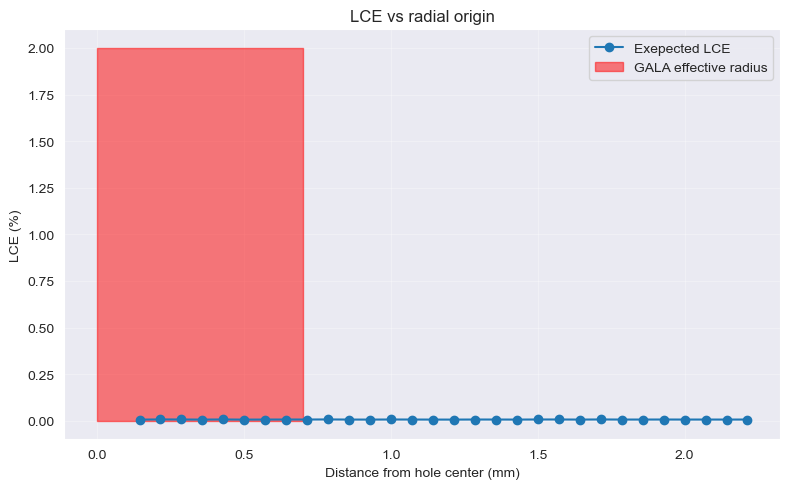

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(bins_radial_centers, counts_radial/3421*0.68, 'o-', label='Exepected LCE')
ax.fill_between([0, 0.7], [2.0, 2.0], alpha=0.5, color = 'red', label = 'GALA effective radius')
# ax.set_ylim(1.4, 2)
ax.set_xlabel('Distance from hole center (mm)')
ax.set_ylabel('LCE (%)')
ax.set_title('LCE vs radial origin')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

## Device Specifications: MICROFC-30035-SMT-TR

In [5]:
# Device specs from OnSemi datasheet
specs = {
    'Device': 'MICROFC-30035-SMT-TR',
    'Active Area (mm²)': '3×3',
    'Microcells': '~5,600',
    'PDE @ 420 nm': '30%',
    'Dark Count Rate': '250 kHz',
    'Crosstalk Probability': '12%',
    'Gain': '~10⁶',
}

print("=" * 50)
print("DEVICE SPECIFICATIONS")
print("=" * 50)
for key, value in specs.items():
    print(f"{key:.<30} {value}")
print("=" * 50)

DEVICE SPECIFICATIONS
Device........................ MICROFC-30035-SMT-TR
Active Area (mm²)............. 3×3
Microcells.................... ~5,600
PDE @ 420 nm.................. 30%
Dark Count Rate............... 250 kHz
Crosstalk Probability......... 12%
Gain.......................... ~10⁶


## 1. Photon Transport Statistics

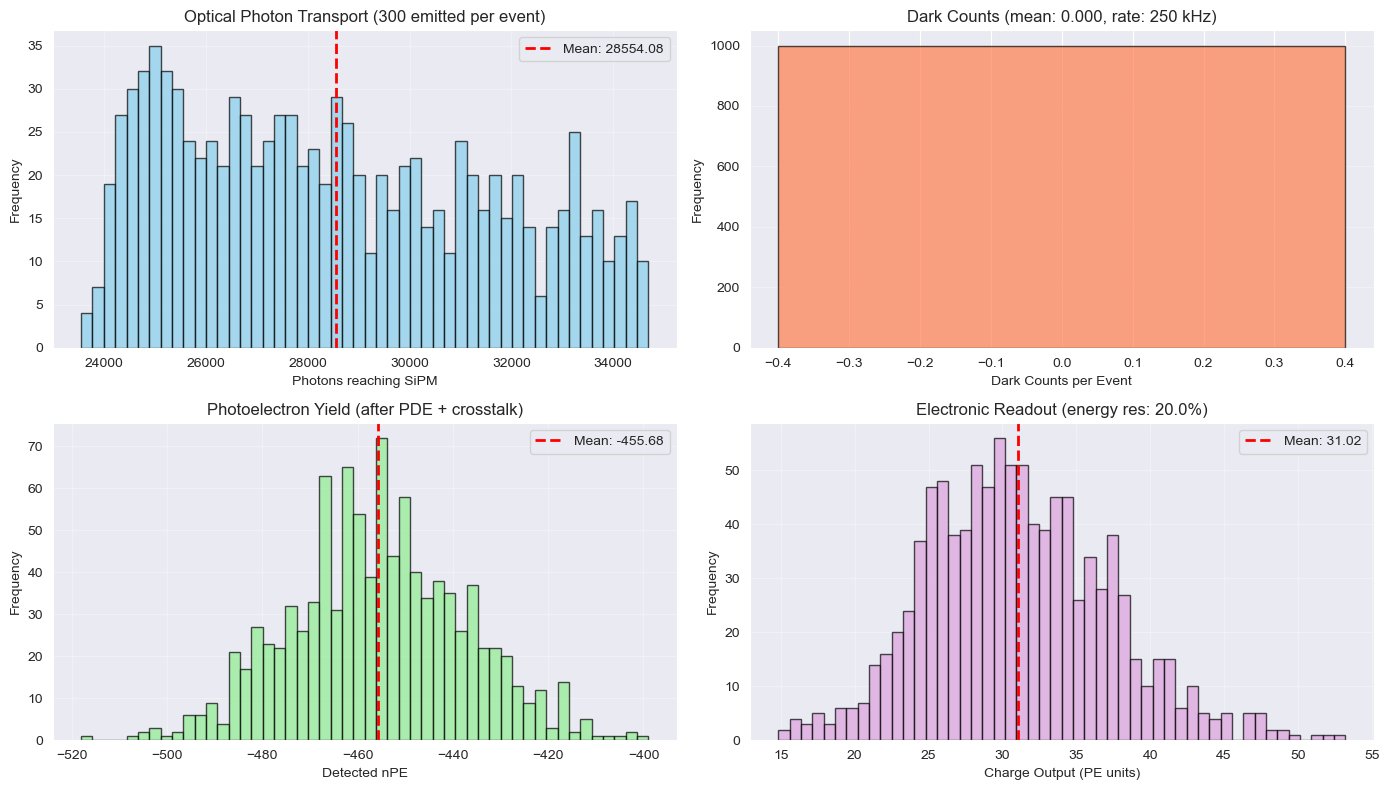

Figure saved: microfc_response_900_32_ct.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Photons reaching SiPM
ax = axes[0, 0]
ax.hist(df['photons_in_SiPM'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax.axvline(df['photons_in_SiPM'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['photons_in_SiPM'].mean():.2f}")
ax.set_xlabel('Photons reaching SiPM')
ax.set_ylabel('Frequency')
ax.set_title('Optical Photon Transport (300 emitted per event)')
ax.legend()
ax.grid(alpha=0.3)

# Dark counts
ax = axes[0, 1]
dark_counts = df['dark_counts'].value_counts().sort_index()
ax.bar(dark_counts.index, dark_counts.values, alpha=0.7, color='coral', edgecolor='black')
ax.set_xlabel('Dark Counts per Event')
ax.set_ylabel('Frequency')
ax.set_title(f'Dark Counts (mean: {df["dark_counts"].mean():.3f}, rate: 250 kHz)')
ax.grid(alpha=0.3, axis='y')

# SiPM nPE
ax = axes[1, 0]
ax.hist(df['sipm_nPE'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
ax.axvline(df['sipm_nPE'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['sipm_nPE'].mean():.2f}")
ax.set_xlabel('Detected nPE')
ax.set_ylabel('Frequency')
ax.set_title('Photoelectron Yield (after PDE + crosstalk)')
ax.legend()
ax.grid(alpha=0.3)

# Charge output
ax = axes[1, 1]
ax.hist(df['sipm_charge_pe'], bins=50, alpha=0.7, color='plum', edgecolor='black')
ax.axvline(df['sipm_charge_pe'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['sipm_charge_pe'].mean():.2f}")
ax.set_xlabel('Charge Output (PE units)')
ax.set_ylabel('Frequency')
ax.set_title(f'Electronic Readout (energy res: {(df["sipm_charge_pe"].std()/df["sipm_charge_pe"].mean())*100:.1f}%)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Figure saved: microfc_response_900_32_ct.png")

## 2. PDE and Crosstalk Analysis

/Users/pablovazquez/miniconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/pablovazquez/miniconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


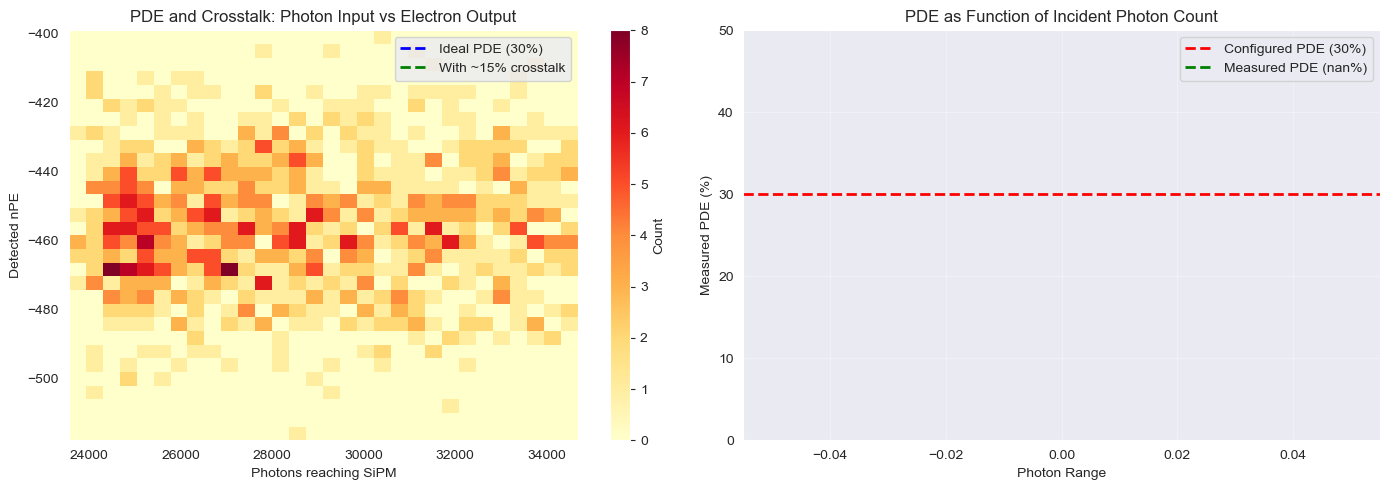


PDE Analysis:
  Configured PDE: 30%
  Measured PDE (overall): -1.60%
  Crosstalk effect: -31.60% above PDE


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Photons vs nPE
ax = axes[0]
h = ax.hist2d(df['photons_in_SiPM'], df['sipm_nPE'], bins=30, cmap='YlOrRd')
# Add theoretical line: nPE = photons * 0.30 (PDE only)
x_theory = np.linspace(0, df['photons_in_SiPM'].max(), 100)
ax.plot(x_theory, x_theory * 0.30, 'b--', linewidth=2, label='Ideal PDE (30%)')
ax.plot(x_theory, x_theory * 0.30 * 1.15, 'g--', linewidth=2, label='With ~15% crosstalk')
ax.set_xlabel('Photons reaching SiPM')
ax.set_ylabel('Detected nPE')
ax.set_title('PDE and Crosstalk: Photon Input vs Electron Output')
ax.legend()
plt.colorbar(h[3], ax=ax, label='Count')

# Calculate measured PDE for different photon ranges
ax = axes[1]
photon_bins = np.arange(5, 45, 5)
measured_pde = []
bin_centers = []
for i in range(len(photon_bins)-1):
    mask = (df['photons_in_SiPM'] >= photon_bins[i]) & (df['photons_in_SiPM'] < photon_bins[i+1])
    if mask.sum() > 0:
        pde = df[mask]['sipm_nPE'].mean() / df[mask]['photons_in_SiPM'].mean()
        measured_pde.append(pde)
        bin_centers.append((photon_bins[i] + photon_bins[i+1])/2)

ax.scatter(bin_centers, np.array(measured_pde)*100, s=100, alpha=0.7, color='darkblue')
ax.axhline(30, color='red', linestyle='--', linewidth=2, label='Configured PDE (30%)')
ax.axhline(np.mean(measured_pde)*100, color='green', linestyle='--', linewidth=2, label=f'Measured PDE ({np.mean(measured_pde)*100:.1f}%)')
ax.set_xlabel('Photon Range')
ax.set_ylabel('Measured PDE (%)')
ax.set_title('PDE as Function of Incident Photon Count')
ax.set_ylim([0, 50])
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPDE Analysis:")
print(f"  Configured PDE: 30%")
print(f"  Measured PDE (overall): {(df['sipm_nPE'].mean() / df['photons_in_SiPM'].mean())*100:.2f}%")
print(f"  Crosstalk effect: {((df['sipm_nPE'].mean() / df['photons_in_SiPM'].mean()) - 0.30)*100:.2f}% above PDE")

## 3. Energy Resolution and Gain Fluctuations

In [8]:
def gaussian(x, mu, sigma, A):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

In [9]:
from scipy.stats import binned_statistic

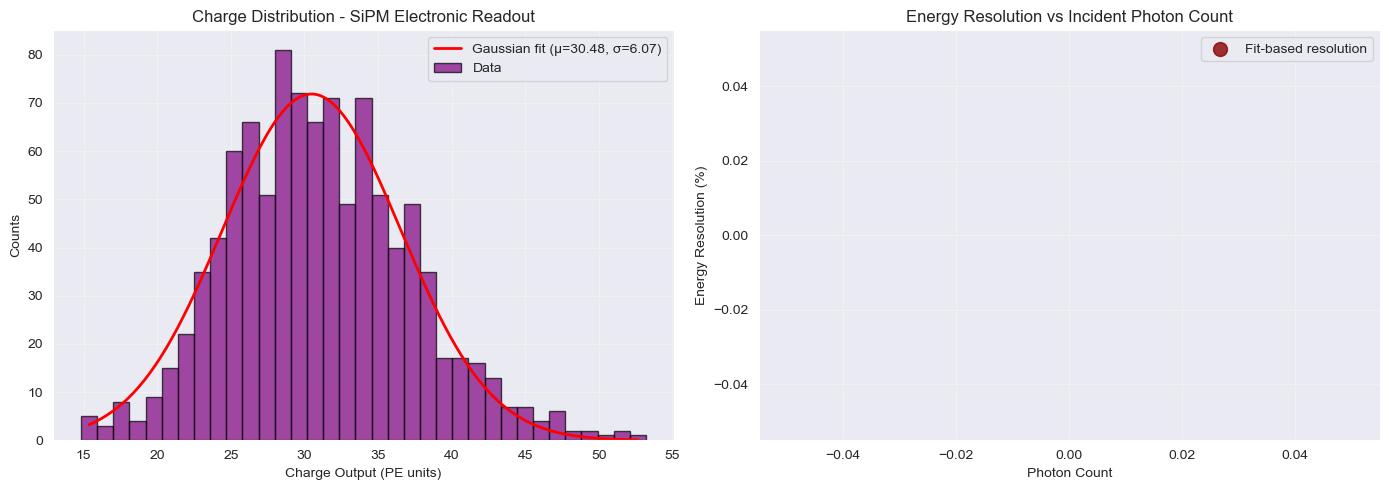


Energy Resolution Analysis:
  No photon bins had enough statistics for a Gaussian fit.
  Configured gain variation: 15% (σ_gain = 0.15 × √nPE)
  Electronic noise: 0.3 PE


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Charge distribution with Gaussian fit
ax = axes[0]
charges = df['sipm_charge_pe'].values
ax.hist(charges, bins=35, alpha=0.7, color='purple', edgecolor='black', label='Data')
counts, bins = np.histogram(charges, bins=35)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Fit Gaussian to the global charge histogram
popt, pcov = curve_fit(
    gaussian,
    bin_centers,
    counts,
    p0=[np.mean(charges), np.std(charges), counts.max()],
    maxfev=10000,
 )
mu, sigma, A = popt
x = np.linspace(bin_centers[0], bin_centers[-1], 200)
ax.plot(x, gaussian(x, mu, sigma, A), 'r-', linewidth=2, label=f'Gaussian fit (μ={mu:.2f}, σ={sigma:.2f})')

ax.set_xlabel('Charge Output (PE units)')
ax.set_ylabel('Counts')
ax.set_title('Charge Distribution - SiPM Electronic Readout')
ax.legend()
ax.grid(alpha=0.3)

# Energy resolution vs photon count
ax = axes[1]
photon_edges = np.arange(df['photons_in_SiPM'].min(), df['photons_in_SiPM'].max() + 2, 3)
resolutions = []
photon_bin_centers = []

for low, high in zip(photon_edges[:-1], photon_edges[1:]):
    mask = (df['photons_in_SiPM'] >= low) & (df['photons_in_SiPM'] < high)
    if mask.sum() <= 10:
        continue

    charges_in_bin = df.loc[mask, 'sipm_charge_pe'].values
    hist_counts, hist_edges = np.histogram(charges_in_bin, bins='auto')
    hist_centers = (hist_edges[:-1] + hist_edges[1:]) / 2

    if len(hist_centers) < 3 or hist_counts.max() == 0:
        continue

    initial_sigma = np.std(charges_in_bin)
    if initial_sigma <= 0 or np.mean(charges_in_bin) <= 0:
        continue

    try:
        popt, pcov = curve_fit(
            gaussian,
            hist_centers,
            hist_counts,
            p0=[np.mean(charges_in_bin), initial_sigma, hist_counts.max()],
            maxfev=10000,
        )
        mu_bin, sigma_bin, A_bin = popt
        if mu_bin > 0 and sigma_bin > 0:
            resolution = abs(sigma_bin / mu_bin) * 100
            resolutions.append(resolution)
            photon_bin_centers.append((low + high) / 2)

    except RuntimeError:
        continue

ax.scatter(photon_bin_centers, resolutions, s=100, alpha=0.8, color='darkred', label='Fit-based resolution')
ax.set_xlabel('Photon Count')
ax.set_ylabel('Energy Resolution (%)')
ax.set_title('Energy Resolution vs Incident Photon Count')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

if resolutions:
    print("\nEnergy Resolution Analysis:")
    print(f"  Mean fit-based resolution: {np.mean(resolutions):.1f}%")
    print(f"  Median fit-based resolution: {np.median(resolutions):.1f}%")
    print(f"  Number of fitted photon bins: {len(resolutions)}")
else:
    print("\nEnergy Resolution Analysis:")
    print("  No photon bins had enough statistics for a Gaussian fit.")
print(f"  Configured gain variation: 15% (σ_gain = 0.15 × √nPE)")
print(f"  Electronic noise: 0.3 PE")

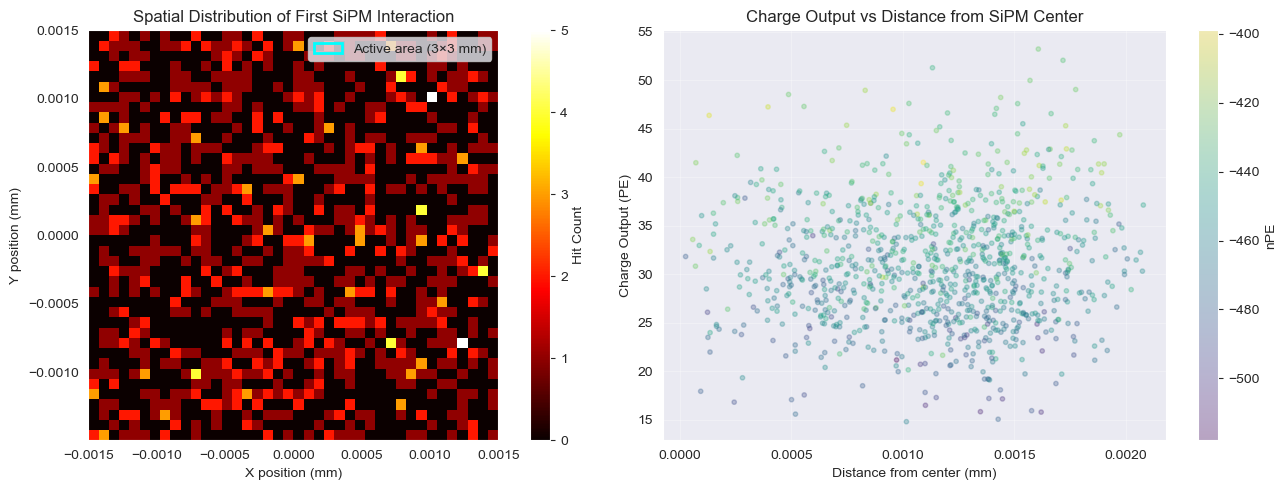


Spatial Distribution:
  Mean distance from center: 0.001 mm
  Max distance from center: 0.002 mm
  Hits within 1.5 mm: 100.0%


In [11]:
# Convert μm to mm for better readability
df['first_sipm_x_mm'] = df['first_sipm_x'] / 1000
df['first_sipm_y_mm'] = df['first_sipm_y'] / 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2D hit map
ax = axes[0]
h = ax.hist2d(df['first_sipm_x_mm'], df['first_sipm_y_mm'], bins=40, cmap='hot')
circle = plt.Circle((0, 0), 1.5, fill=False, edgecolor='cyan', linewidth=2, label='Active area (3×3 mm)')
ax.add_patch(circle)
ax.set_xlabel('X position (mm)')
ax.set_ylabel('Y position (mm)')
ax.set_title('Spatial Distribution of First SiPM Interaction')
ax.set_aspect('equal')
ax.legend()
plt.colorbar(h[3], ax=ax, label='Hit Count')

# Charge distribution vs position
ax = axes[1]
r = np.sqrt(df['first_sipm_x_mm']**2 + df['first_sipm_y_mm']**2)
h = ax.scatter(r, df['sipm_charge_pe'], alpha=0.3, s=10, c=df['sipm_nPE'], cmap='viridis')
ax.set_xlabel('Distance from center (mm)')
ax.set_ylabel('Charge Output (PE)')
ax.set_title('Charge Output vs Distance from SiPM Center')
plt.colorbar(h, ax=ax, label='nPE')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSpatial Distribution:")
print(f"  Mean distance from center: {r.mean():.3f} mm")
print(f"  Max distance from center: {r.max():.3f} mm")
print(f"  Hits within 1.5 mm: {(r <= 1.5).sum() / len(r) * 100:.1f}%")

In [12]:
def energy_resolution_FWHM(sigma, mu):
    return sigma * 2 *np.sqrt(2 * np.log(2)) / mu

In [13]:
sigma = np.array([2.20, 2.74, 3.76, 4.59, 5.24, 5.87, 8.27, 11.70])
mu = np.array([3.50, 6.57, 12.58, 18.61, 24.56, 30.62, 60.68,120])
photons = np.array([150, 300, 600, 900, 1200, 1500, 3000, 6000])

resolution_photons = energy_resolution_FWHM(sigma, mu) * 100

In [14]:
sigma_reflections = np.array([3.12, 5.07, 7.25, 8.93, 10.25, 11.48, 16.16, 22.88])
mu_reflections = np.array([12.18, 23.71, 49.33, 73.73, 98.15, 122.50, 244.46, 488.14])

photons_reflections = np.array([150, 300, 600, 900, 1200, 1500, 3000, 6000])

resolution_photons_reflections = energy_resolution_FWHM(sigma_reflections, mu_reflections) * 100

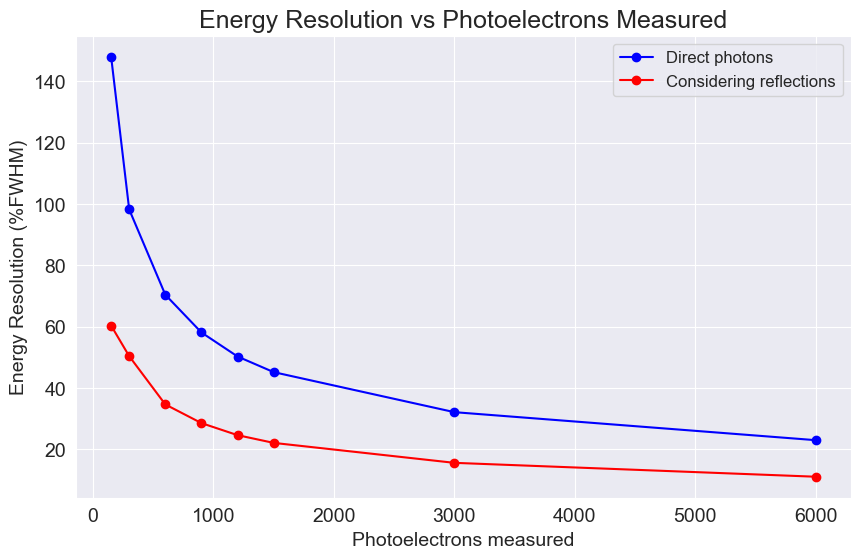

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(photons, resolution_photons, 'o-', color='blue', label = 'Direct photons');
plt.plot(photons_reflections, resolution_photons_reflections, 'o-', color = 'red', label='Considering reflections');
plt.xlabel('Photoelectrons measured', fontsize = 14);
plt.ylabel('Energy Resolution (%FWHM)', fontsize = 14);
plt.title('Energy Resolution vs Photoelectrons Measured', fontsize = 18);
plt.legend(fontsize = 12);
plt.xticks(fontsize = 14);
plt.yticks(fontsize = 14);

In [16]:
sigma_ct = np.array([2.74, 3.02, 3.28, 3.56]) # , 3.77, 3.97, 4.15
mu_ct = np.array([6.57, 7.09, 7.61, 8.16]) # , 8.69, 9.20, 9.76

sigma_ct_900 =  np.array([4.59, 5.08, 5.21, 5.57, 5.80, 6.02]) # , 3.77, 3.97, 4.15
mu_ct_900 = np.array([18.71, 20.56, 21.04, 21.87, 22.75, 23]) # , 8.69, 9.20, 9.76

ct_levels = np.array([7, 17, 27, 37])# 47, 57, 67 
ct_levels_900 = np.array([7, 17, 22, 27, 32, 37])# 47, 57, 67 

In [17]:
resolution_ct = energy_resolution_FWHM(sigma_ct, mu_ct) * 100
resolution_ct_900 = energy_resolution_FWHM(sigma_ct_900, mu_ct_900) * 100

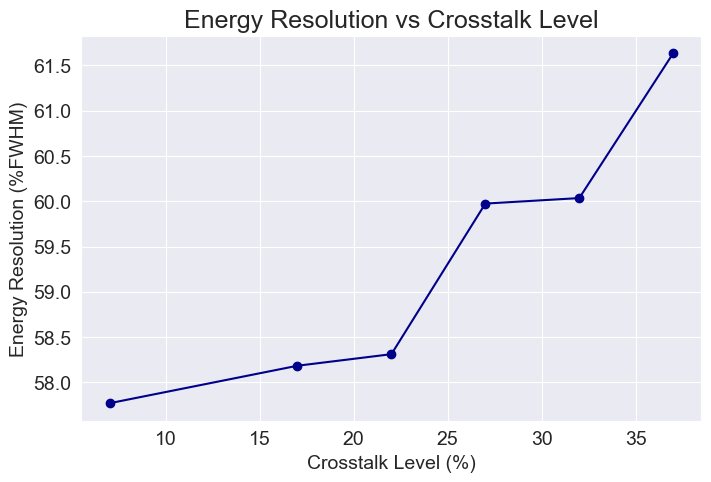

In [18]:
plt.figure(figsize=(8, 5))
# plt.plot(ct_levels, resolution_ct, 'o-', color='darkorange');
plt.plot(ct_levels_900, resolution_ct_900, 'o-', color='darkblue');
plt.xlabel('Crosstalk Level (%)', fontsize=14);
plt.ylabel('Energy Resolution (%FWHM)', fontsize=14);
plt.title('Energy Resolution vs Crosstalk Level', fontsize=18);
plt.xticks(fontsize=14);
plt.yticks(fontsize=14);

In [19]:
sigma_gv = np.array([2.74, 2.80, 2.83, 2.88, 3]) 
mu_gv = np.array([6.57, 6.52, 6.53, 6.51,  6.46]) 
gv_levels = np.array([12, 24, 30, 36, 48])

resolution_gv = energy_resolution_FWHM(sigma_gv, mu_gv) * 100

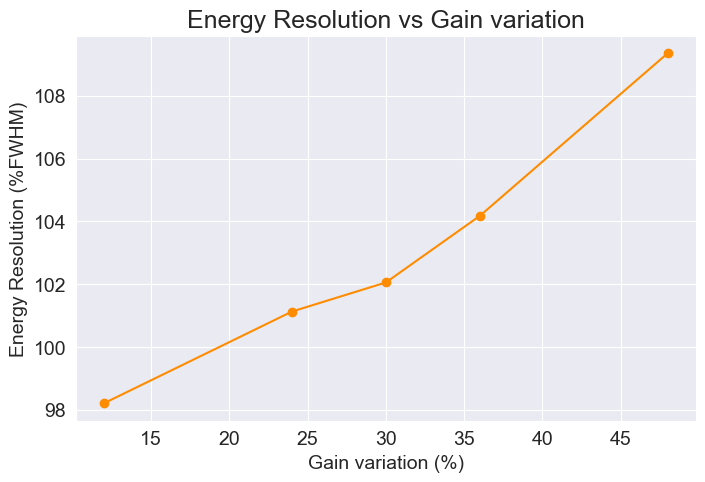

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(gv_levels, resolution_gv, 'o-', color='darkorange');
plt.xlabel('Gain variation (%)', fontsize=14);
plt.ylabel('Energy Resolution (%FWHM)', fontsize=14);
plt.title('Energy Resolution vs Gain variation', fontsize=18);
plt.xticks(fontsize=14);
plt.yticks(fontsize=14);

In [21]:
25/300

0.08333333333333333